**ACHRAF JARRAR**

Project Goal:
The objective of this project is to develop a method for predicting future prices of Microsoft stock. This predictive insight is crucial for making informed investment decisions and strategic trading.
The project aims to:

* Forecast Stock Prices : Utilize historical data to predict future stock prices with LSTM. This will give us information on how the stock's price would change over time in the future.

* Risk Assessment through Monte Carlo Simulation: Apply the Geometric Brownian Motion (GBM) model within the Monte Carlo framework to assess risk and explore worst-case scenarios.

In [ ]:
!pip install yfinance

In [67]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [25]:
msft = yf.download('MSFT', start='2020-01-01', end='2023-12-30')
print(msft)

[*********************100%***********************]  1 of 1 completed

Price                       Adj Close       Close        High         Low  \
Ticker                           MSFT        MSFT        MSFT        MSFT   
Date                                                                        
2020-01-02 00:00:00+00:00  153.938187  160.619995  160.729996  158.330002   
2020-01-03 00:00:00+00:00  152.021423  158.619995  159.949997  158.059998   
2020-01-06 00:00:00+00:00  152.414368  159.029999  159.100006  156.509995   
2020-01-07 00:00:00+00:00  151.024673  157.580002  159.669998  157.320007   
2020-01-08 00:00:00+00:00  153.430237  160.089996  160.800003  157.949997   
...                               ...         ...         ...         ...   
2023-12-22 00:00:00+00:00  372.543915  374.579987  375.179993  372.709991   
2023-12-26 00:00:00+00:00  372.623505  374.660004  376.940002  373.500000   
2023-12-27 00:00:00+00:00  372.036713  374.070007  375.059998  372.809998   
2023-12-28 00:00:00+00:00  373.240112  375.279999  376.459991  374.160004   

### I) Monte Carlo Simulation

A Monte Carlo simulation applies a selected model (that specifies the behavior of an instrument) to a large set of random trials in an attempt to produce a plausible set of possible future outcomes. In regard to simulating stock prices, the most common model is geometric Brownian motion (GBM).


1) What is the GBM model ?

A Geometric Brownian $(S_t)$ motion with parameters $\mu$ and $\sigma > 0 $ has the following expression :
$S_t = S_0 \exp \left( \sigma B_t + \mu t \right)$

Where $B_t$ is the standard Brownian motion.


2) Why would we use GBM ?

* A GBM process only assumes positive values, just like real stock prices.
* A GBM process shows the same kind of 'roughness' in its paths as we see in real stock prices : It has irregular, unpredictable fluctuations observed in the path of the stock price over time which aligns with stock prices which exhibit fluctuations with frequent ups and downs of variyng magnitudes.
* The logarithmic returns are normally distributed which is immediate using the formula above and calculating :

$$
\log \left( \frac{S_t}{S_{t-1}} \right) = \sigma \left( B_t - B_{t-1} \right) + \mu
$$

where $\epsilon_t = (B_t - B_{t-1}) $ follows a standard normal distribution.

Remark : $\epsilon_{t_1},..., \epsilon_{t_n}$ are independent because Brownian motion has independent increments.


In [26]:
msft['Log_Returns'] = np.log(msft['Close'] / msft['Close'].shift(1)).dropna()

Date
2020-01-02 00:00:00+00:00         NaN
2020-01-03 00:00:00+00:00   -0.012530
2020-01-06 00:00:00+00:00    0.002581
2020-01-07 00:00:00+00:00   -0.009160
2020-01-08 00:00:00+00:00    0.015803
                               ...   
2023-12-22 00:00:00+00:00    0.002780
2023-12-26 00:00:00+00:00    0.000214
2023-12-27 00:00:00+00:00   -0.001576
2023-12-28 00:00:00+00:00    0.003229
2023-12-29 00:00:00+00:00    0.002023
Name: Log_Returns, Length: 1006, dtype: float64


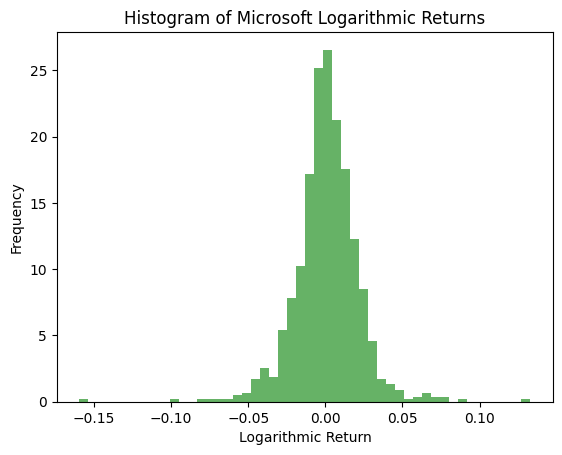

In [4]:
plt.hist(msft['Log_Returns'].dropna(), bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of Microsoft Logarithmic Returns')
plt.xlabel('Logarithmic Return')
plt.ylabel('Frequency')
plt.show()

The histogram shows that the Logarithmic Returns of the stock do follow a Standard Normal distribution which encourages us to use GBM model.

3) How are we going to use Geometric Brownian Motion ?

The Geometric Brownian motion we will use will be the following :

$S_t = S_0 e^{\mu t} e^{\sigma B_t - \frac{\sigma^2 t}{2}}$

where:

- $S_t$ is the stock price at time $t$,
- $S_0$ is the initial stock price,
- $\mu$ is a term to be estimated,
- $\sigma$ is a term to be estimated,
- $B_t$ is the standard Brownian motion (Wiener process).

It is often used in Finance, especially for the future evolution of stock prices. However, this formula is for continuous time. In our case, we have discrete time steps (1 day). So in order to have a discrete-Time approximation we need to break time into small intervals of size $dt$. Naturally, since we consider one year in the future, $dt = 1 / 365 $ which aligns with daily increments. In other terms, $t_{i+1} - t_i = dt
\text{, for all } i \in \{0, 1, 2, \ldots, 364\}$.
Consequently, $\frac{S_{t_{i+1}}}{S_{t_i}} = \exp\left[\left(\mu - \frac{\sigma^2}{2}\right) dt + \sigma \sqrt{dt} \epsilon_i\right]$

With $\epsilon_i $ is a random variable drawn from a standard normal distribution (representing the stochastic component).

$\epsilon_i$ are i.i.d because Brownian motion has independent increments.


### Estiamtion of $\mu$ and $\sigma$

Considering $\log\left(\frac{S_{t_{i+1}}}{S_{t_i}}\right) = \left(\mu - \frac{\sigma^2}{2}\right) dt + \sigma \sqrt{dt} \epsilon_i$

Denote $\mu_{\text{log}}$ as the estimator of the logarithmic mean.  
Denote $\sigma_{\text{log}}$ as the estimator of the logarithmic standard deviation.

$$
\mu_{\text{log}} = \left(\mu - \frac{\sigma^2}{2}\right) dt
$$

$$
\sigma^2 dt = \sigma_{\text{log}}^2
$$

Thus, we have:

$$
\sigma = \frac{\sigma_{\text{log}}}{\sqrt{dt}}
$$

$$
\mu = \frac{\mu_{\text{log}}}{dt} + \frac{\sigma^2}{2}
$$

In [5]:
msft_close = msft['Close']
returns_msft = msft_close.pct_change().dropna()
print(returns_msft)

Ticker                         MSFT
Date                               
2020-01-03 00:00:00+00:00 -0.012452
2020-01-06 00:00:00+00:00  0.002585
2020-01-07 00:00:00+00:00 -0.009118
2020-01-08 00:00:00+00:00  0.015928
2020-01-09 00:00:00+00:00  0.012493
...                             ...
2023-12-22 00:00:00+00:00  0.002784
2023-12-26 00:00:00+00:00  0.000214
2023-12-27 00:00:00+00:00 -0.001575
2023-12-28 00:00:00+00:00  0.003235
2023-12-29 00:00:00+00:00  0.002025

[1005 rows x 1 columns]


In [27]:
# Display logarithmic returns
log_returns_msft = msft['Log_Returns'].dropna()
print(log_returns_msft)

Date
2020-01-03 00:00:00+00:00   -0.012530
2020-01-06 00:00:00+00:00    0.002581
2020-01-07 00:00:00+00:00   -0.009160
2020-01-08 00:00:00+00:00    0.015803
2020-01-09 00:00:00+00:00    0.012416
                               ...   
2023-12-22 00:00:00+00:00    0.002780
2023-12-26 00:00:00+00:00    0.000214
2023-12-27 00:00:00+00:00   -0.001576
2023-12-28 00:00:00+00:00    0.003229
2023-12-29 00:00:00+00:00    0.002023
Name: Log_Returns, Length: 1005, dtype: float64


In [28]:
dt = 1 / 365
mu_log = log_returns_msft.mean()
sigma_log = log_returns_msft.std()

In [29]:
mu = mu_log / dt + (sigma_log**2) / 2
sigma = sigma_log / np.sqrt(dt)
print(sigma,mu)
start_price = 376.040009  # At 2023-12-29

0.39288430053722545 0.30915552919872336


In [30]:
def stock_monte_carlo(start_price, days, mu, sigma):
    price = np.zeros(days)
    price[0] = start_price
    for t in range(1, days):
        eps_t= np.random.normal(loc=0, scale=1)
        price[t] = price[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * eps_t)

    return price

## Let's visualize how the evolution of stock prices would look like

Text(0.5, 1.0, 'Monte Carlo Analysis for Microsoft')

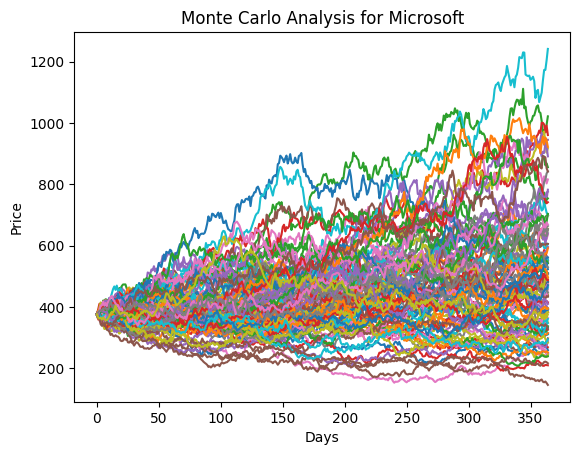

In [31]:
for run in range(1,100):
    plt.plot(stock_monte_carlo(start_price,365,mu,sigma))
plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Analysis for Microsoft')

# Let's run 10000 simulations

In [32]:
runs = 10000
days = 365
simulations = np.zeros(runs)

for run in range(1,runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]

We can do many studies on these simulations : For example we can calculate the average final price (in 365 days) and see the worst case scenario with a 99% confidence interval. This actually corresponds the Value at Risk.

Text(0.5, 1.0, 'Final price distribution for Microsoft Stock after 365 days')

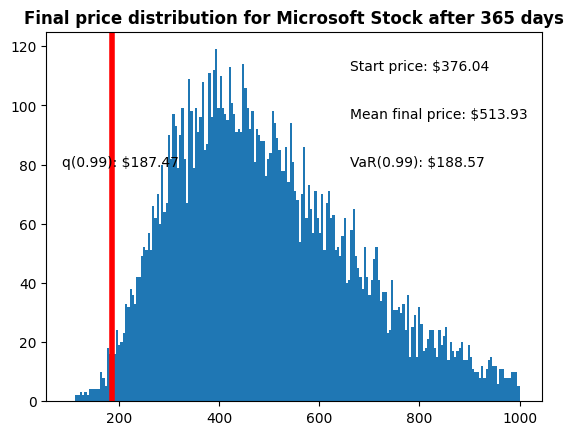

In [39]:
q = np.percentile(simulations,1)

plt.hist(simulations,bins=200,range = [100,1000])

plt.figtext(0.6,0.8,s="Start price: $%.2f" %start_price)

plt.figtext(0.6,0.7,"Mean final price: $%.2f" % simulations.mean())

plt.figtext(0.6,0.6,"VaR(0.99): $%.2f" % (start_price -q,))

plt.figtext(0.15,0.6, "q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title(u"Final price distribution for Microsoft Stock after %s days" %days, weight='bold')

In this case, the mean final price was 513.93 Dollars and VaR with 99% was 188.57 Dollars. which means that with 99% probability, the price won't go below 187.47 Dollars

2) Using LSTM to forecast daily prices of Microsoft for one year

We will need more data in order for the lstm model to be as accurate as possible. For that we will take up to 9 years of data.

We will do the forecast on a short period of time (about 3 months).

We will use a sequence length of 5 days.

In [40]:
msft = yf.download('MSFT', start='2010-01-01', end='2019-01-05')
msft.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [41]:
msft = msft.drop(['Date', 'Adj Close'], axis = 1)

<ipython-input-41-edbcb1569f0a>:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  msft = msft.drop(['Date', 'Adj Close'], axis = 1)


In [42]:
msft = msft.dropna()
msft.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
0,30.950001,31.100000,30.590000,30.620001,38409100
1,30.959999,31.100000,30.639999,30.850000,49749600
2,30.770000,31.080000,30.520000,30.879999,58182400
3,30.450001,30.700001,30.190001,30.629999,50559700
4,30.660000,30.879999,30.240000,30.280001,51197400


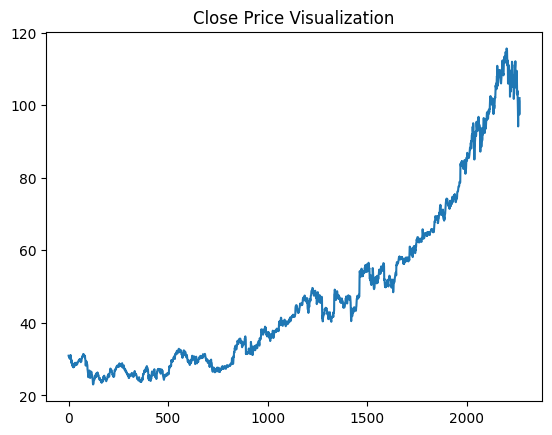

In [43]:
plt.title("Close Price Visualization")
plt.plot(msft.Close)

In [44]:
data = msft.Close

## Split data into train and test data

In [45]:
train_close = pd.DataFrame(data[0:int(len(data)*0.8)])
rest_close = pd.DataFrame(data[int(len(data)*0.8): int(len(data))])

In [46]:
validate_close = pd.DataFrame(rest_close[0:int(len(rest_close)*0.8)])
test_close = pd.DataFrame(rest_close[int(len(rest_close)*0.8): int(len(rest_close))])

In [47]:
print(test_close.shape, validate_close.shape,train_close.shape)

(91, 1) (363, 1) (1813, 1)


## Use scaler

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [49]:
data_training_array = scaler.fit_transform(train_close)

In [50]:
data_validation_array = scaler.transform(validate_close)

In [51]:
data_test_array = scaler.transform(test_close)

In [52]:
# Sequence length
sequence_length = 5
x_train, y_train = [], []
x_validation, y_validation = [], []
x_test, y_test = [], []

for i in range(sequence_length, data_training_array.shape[0]):
    x_train.append(data_training_array[i-sequence_length:i])
    y_train.append(data_training_array[i, 0])

combined_validation_data = np.concatenate((data_training_array[-sequence_length:], data_validation_array), axis=0)

# Prepare validation sequences
for i in range(sequence_length, combined_validation_data.shape[0]):
    x_validation.append(combined_validation_data[i-sequence_length:i])
    y_validation.append(combined_validation_data[i, 0])


combined_test_data = np.concatenate((data_validation_array[-sequence_length:], data_test_array), axis=0)

# Prepare test sequences
for i in range(sequence_length, combined_test_data.shape[0]):
    x_test.append(combined_test_data[i-sequence_length:i])
    y_test.append(combined_test_data[i, 0])

# Convert lists to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)
x_validation, y_validation = np.array(x_validation), np.array(y_validation)
x_test, y_test = np.array(x_test), np.array(y_test)

# Print shapes to verify
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_validation shape:", x_validation.shape)
print("y_validation shape:", y_validation.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1808, 5, 1)
y_train shape: (1808,)
x_validation shape: (363, 5, 1)
y_validation shape: (363,)
x_test shape: (91, 5, 1)
y_test shape: (91,)


In [81]:
model = Sequential()
model.add(LSTM(units = 50, return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60,return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units = 1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [82]:
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                       │ (None, 5, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 5, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 60)                  │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              61 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,101 (144.93 KB)

 Trainable params: 37,101 (144.93 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, validation_data = (x_validation, y_validation) ,epochs = 50)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0017 - val_loss: 0.0047
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 0.0115
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 0.0166
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0104
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 0.0135
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 0.0132
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 - val_loss: 0.0070
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 0.0080
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0044
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0066
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9587e-04 - 

In [91]:
# Make predictions on the test set
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)
y_test_original= scaler.inverse_transform(y_test.reshape(-1, 1))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step


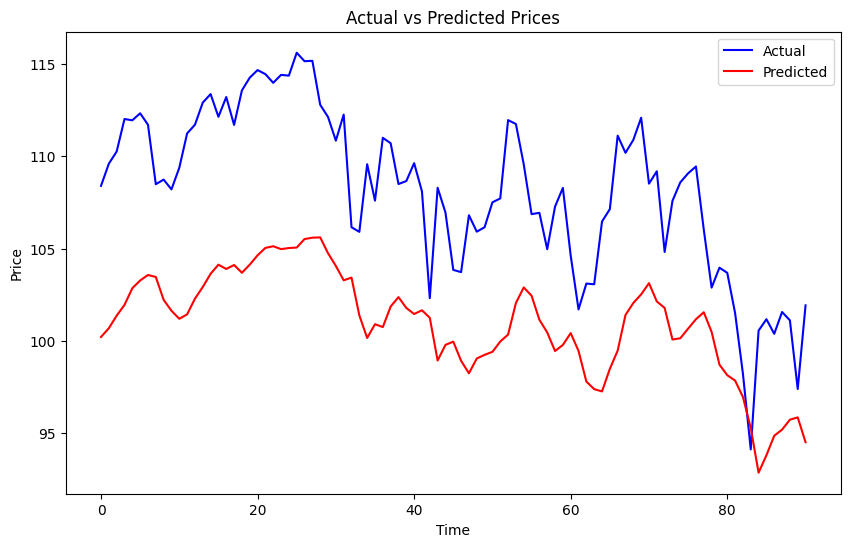

In [92]:
# Plot the actual values against the predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, color='blue', label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [93]:
mse = mean_squared_error(y_test_original, predictions)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 58.615622654270666


In [94]:
mae = mean_absolute_error(y_test_original, predictions)
print(f"Mean Absolute Error (MAE): {mae}")


Mean Absolute Error (MAE): 7.255860213395003


In [95]:
correlation = np.corrcoef(y_test_original.flatten(), predictions.flatten())[0, 1]
print(f"Correlation Coefficient: {correlation:.2f}")

Correlation Coefficient: 0.85


The result is not perfect but it's not far from reality. The model has identified the trend and the fluctuations (Which is demonstrated by the Correlation Coefficient), the values aren't exact(High MSE and MAE) but the evolution of prices is really close to what we see in the reality. Based on this we can have an insight on the evolution of prices over time.

To make the model more precise : We can do hyperparameters tuning using Optuna.
We can also do Features Engeneering which might enhance the precision of the model

Conclusion : These two tools can help us understand the dynamics of a market or at least give us insights on the worst case scenarios based on statistical strategies.  